### Import modules and data

In [1]:
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import libpysal
import esda
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# data import
DATA_PATH = "../data/updated_data.geojson"
gdf = gpd.read_file(DATA_PATH)

# Car Leroux model

### Build adjacency from your GeoDataFrame

In [3]:
gdf = gdf.reset_index(drop=True)

n = len(gdf)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = gdf.sindex  # spatial index

for i, geom in enumerate(gdf.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(gdf.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1

Correlation Matrix:


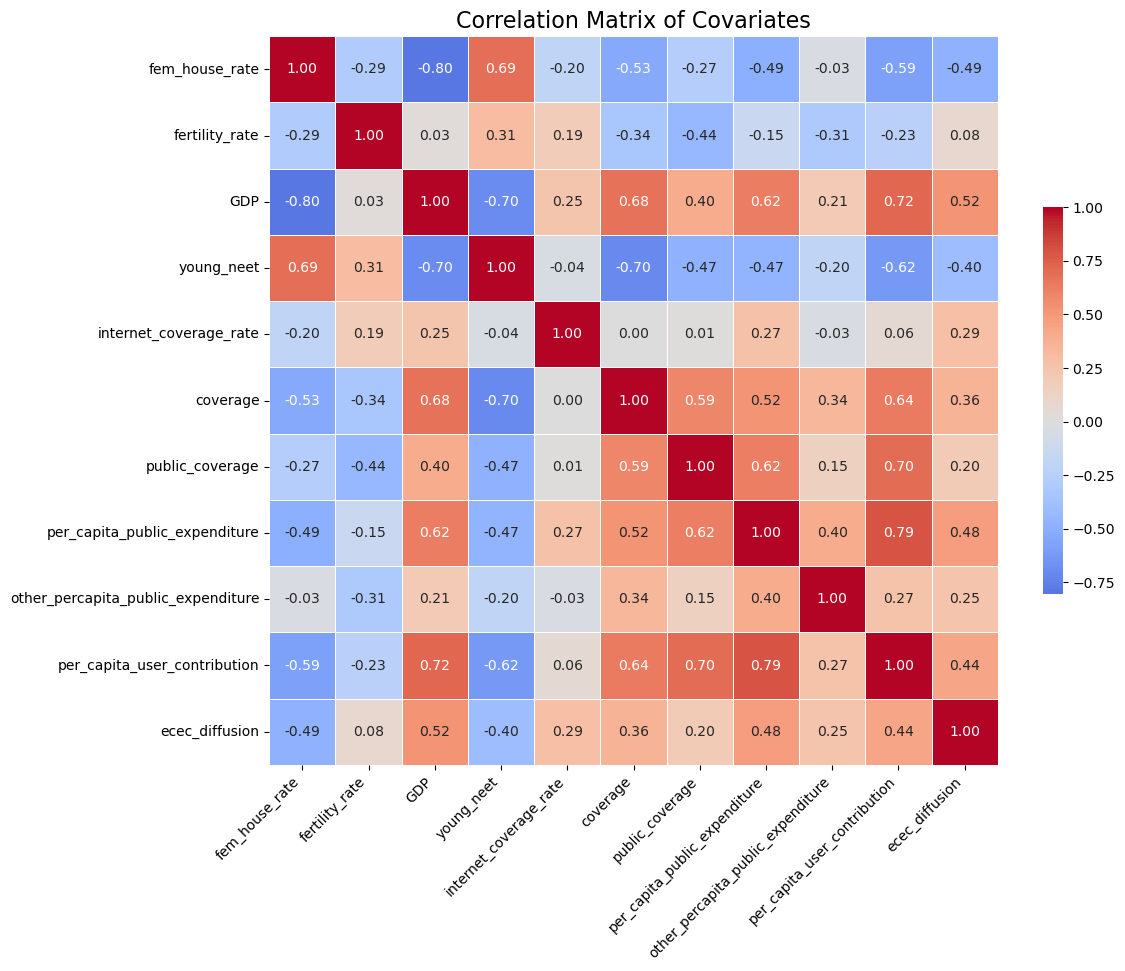

In [31]:
# 2. Define the list of covariates
selected_covariates = [
    'fem_house_rate',
    'fertility_rate',
    'GDP',
    'young_neet',
    'internet_coverage_rate',
    'coverage',
    'public_coverage',
    'per_capita_public_expenditure',
    'other_percapita_public_expenditure',
    'per_capita_user_contribution',
    'ecec_diffusion'
]

# 3. Create a subset of the data
# We drop rows with missing values (NaN) to ensure accurate correlation calculation
df_subset = gdf[selected_covariates].dropna()

# 4. Calculate the Correlation Matrix
# method='pearson' is standard. Use 'spearman' if relations are non-linear.
corr_matrix = df_subset.corr(method='pearson')

# --- Option A: Print the text matrix ---
print("Correlation Matrix:")
# --- Option B: Plot a Heatmap (Recommended) ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,         # Show the numbers inside the boxes
    fmt=".2f",          # Format to 2 decimal places
    cmap='coolwarm',    # Blue for negative, Red for positive
    center=0,           # Center the colormap at 0
    square=True,        # Make cells square-shaped
    linewidths=.5,      # Add lines between cells
    cbar_kws={"shrink": .5}
)

plt.title('Correlation Matrix of Covariates', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate x labels for readability
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Prepare data

In [60]:
selected_covariates = ['fem_house_rate',
                       'fertility_rate',
                       'GDP',
                       'young_neet',
                       'internet_coverage_rate',
                       'coverage',
                       'public_coverage',
                       'per_capita_public_expenditure',
                       'other_percapita_public_expenditure',
                       'per_capita_user_contribution',
                       'ecec_diffusion'
                      ]

X = gdf.select_dtypes(include="number")

# Select only the desired covariates
X = X[selected_covariates]

#X = gdf.select_dtypes(include="number").drop(columns=["fem_empl_rate"])
X = X.fillna(X.mean())  # simple sanitization
#X= X[selected_covariates]
y = gdf["fem_empl_rate"].values
y = y / 100
y = np.log(y / (1 - y))
x_offset = gdf["mal_empl_rate"].values
x_offset=x_offset/100   
x_offset = np.log(x_offset / (1 - x_offset))
X_standardized = (X - X.mean()) / X.std()

stan_data = {
    "N": len(gdf),
    "P": X_standardized.shape[1],
    "y": y,
    "X": X_standardized.values,
    "x_offset": x_offset,
    "W": W
}



In [33]:
X_standardized.shape[1]

10

### Compile the CAR model

In [34]:
from cmdstanpy import CmdStanModel
stan_code = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}


data {
  int<lower=1> N;                       // number of regions
  int<lower=1> P;                       // number of covariates
  matrix[N, P] X;                        // design matrix
  vector[N] y;                          // response variable
  vector[N] x_offset;                  // offset 
  matrix<lower=0, upper=1>[N, N] W;    // adjacency matrix
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
  real alpha;                          // intercept
  vector[P] beta;                      // coefficients
  real<lower=0> sigma2;                 
  real<lower=0> tau2;                  // CAR precision
  vector[N] phi;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}


model {
  // Priors
  alpha ~ normal(0, 1);
  beta  ~ normal(0, 1);
  sigma2 ~ gamma(3,2);
  tau2  ~ gamma(3, 2);
  rho   ~ beta(2,2);

  // CAR Leroux prior
  phi ~ car_leroux(tau2, rho, W, D, lambda, N);

  // Likelihood
  y ~ normal(alpha + X * beta + phi, sqrt(sigma2));

}

"""

# Write stan model to file
stan_file = "./car_leroux_model.stan"
with open(stan_file, "w") as f:
    print(stan_code, file=f)


In [35]:
# Compile stan model
from cmdstanpy import CmdStanModel
stan_file = "./car_leroux_model.stan"
model = CmdStanModel(stan_file=stan_file)

17:58:00 - cmdstanpy - INFO - compiling stan file E:\Bayesian-Statistics-Project\sandbox\seminar\car_leroux_model.stan to exe file E:\Bayesian-Statistics-Project\sandbox\seminar\car_leroux_model.exe
18:00:10 - cmdstanpy - INFO - compiled model executable: E:\Bayesian-Statistics-Project\sandbox\seminar\car_leroux_model.exe


### Run the CAR model

In [61]:
fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=10000,
    iter_sampling=2000,
    seed=42,
    adapt_delta=0.99,
    max_treedepth=30,
    force_one_process_per_chain=True
)

18:09:07 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/12000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/12000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/12000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/12000 [00:00<?, ?it/s, (Warmup)]

18:11:22 - cmdstanpy - INFO - CmdStan done processing.
18:11:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'car_leroux_model.stan', line 68, column 2 to column 22)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'car_leroux_model.stan', line 68, column 2 to column 22)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'car_leroux_model.stan', line 68, column 2 to column 22)
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'car_leroux_model.stan', line 68, column 2 to column 22)
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'car_leroux_model.stan', line 68, column 2 to column 22)
Consider re-running with show_console=True if the above output is unclear!


In [68]:
pd.set_option('display.max_rows', None)

In [69]:
fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,410.030000,1.900040,30.540500,30.195600,363.008000,407.978000,463.217000,265.8030,555.896,3.07492,1.01729
alpha,0.048032,0.007066,0.070628,0.060576,-0.060593,0.046615,0.158950,110.6790,181.421,1.28039,1.06481
beta[1],-0.324366,0.001583,0.044150,0.044936,-0.396690,-0.324359,-0.251826,776.0970,1771.350,8.97824,1.00198
beta[2],-0.213074,0.001237,0.033368,0.032988,-0.268783,-0.213271,-0.158053,725.3860,1490.800,8.39160,1.00202
beta[3],0.037903,0.000909,0.031647,0.031050,-0.014202,0.038368,0.090921,1212.0900,2326.650,14.02200,1.00370
beta[4],-0.088120,0.000929,0.032261,0.031873,-0.141896,-0.087660,-0.036374,1212.7700,2003.930,14.02990,1.00143
beta[5],-0.026967,0.000490,0.017670,0.017464,-0.056034,-0.026869,0.002453,1283.7200,2335.130,14.85060,1.00406
beta[6],0.017543,0.000786,0.028206,0.027845,-0.028000,0.017198,0.063763,1295.2500,2047.700,14.98400,1.00554
beta[7],0.017691,0.000874,0.029526,0.029753,-0.030808,0.017738,0.065729,1144.5400,2164.010,13.24060,1.00651
beta[8],0.027299,0.001081,0.035458,0.035405,-0.032412,0.027974,0.084045,1097.6600,1568.350,12.69830,1.00567


In [64]:
rho_summary = fit.summary().loc[['sigma2','rho']]
print(rho_summary)

            Mean      MCSE    StdDev       MAD        5%       50%       95%  \
sigma2  0.002405  0.000079  0.001441  0.001241  0.000697  0.002116  0.005165   
rho     0.812023  0.002543  0.083000  0.083097  0.661006  0.822920  0.929108   

        ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
sigma2   280.487   619.361     3.24480  1.01659  
rho      721.505   695.983     8.34669  1.00827  


In [65]:
import arviz as az
cmdstanpy_data = az.from_cmdstanpy(fit)

C:\Users\admin\miniconda3\envs\stan\Lib\site-packages\arviz\plots\traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (122), generating only 20 plots
  warnings.warn(


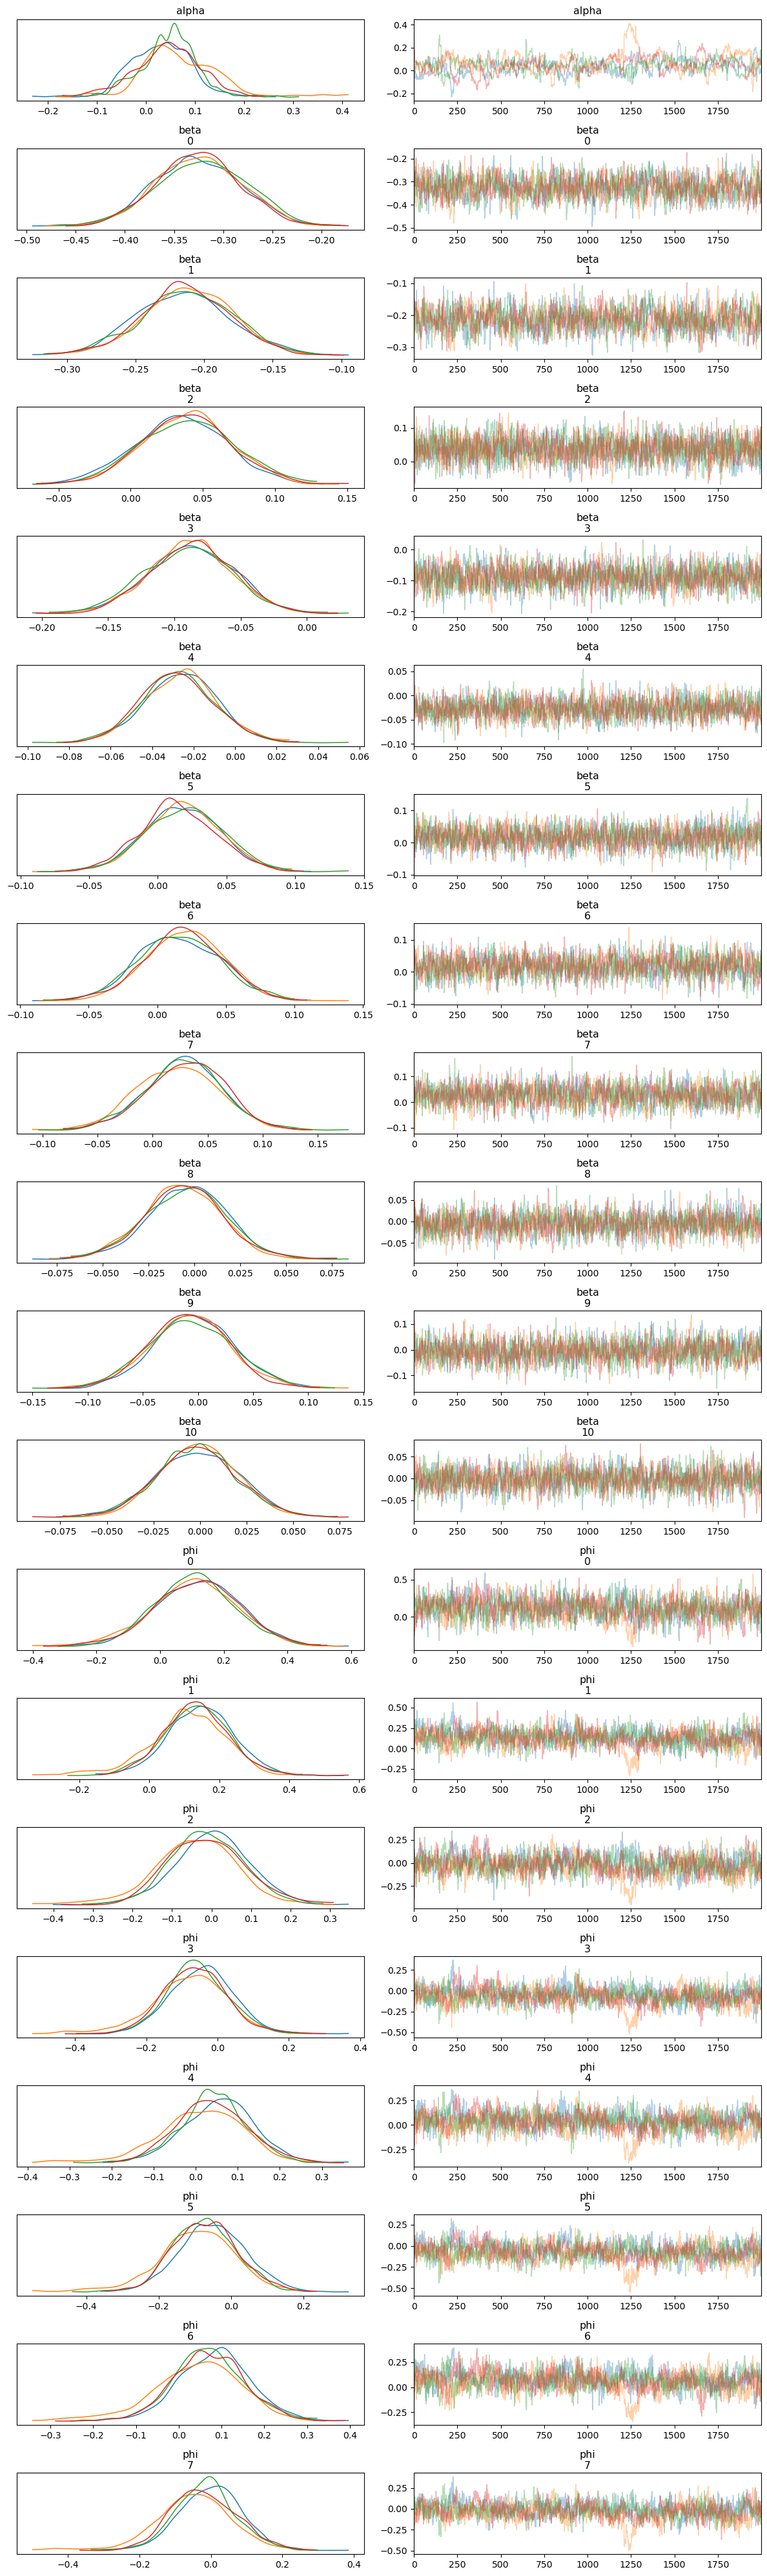

In [66]:
import matplotlib.pyplot as plt
az.plot_trace(cmdstanpy_data, compact=False)
plt.tight_layout()
plt.show()

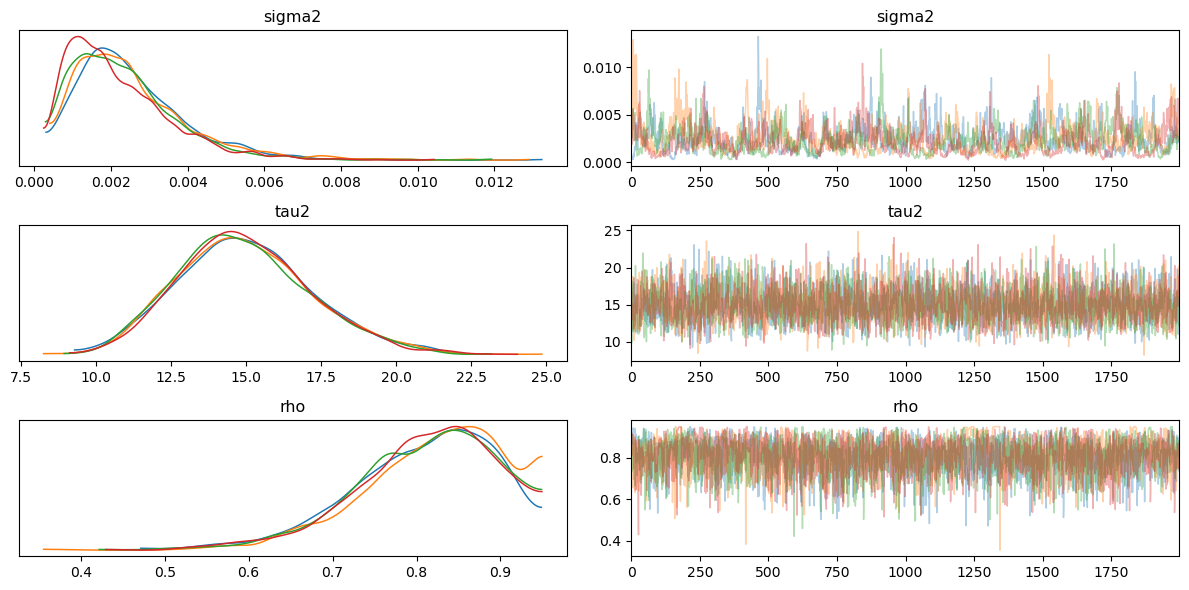

In [70]:
import arviz as az
import matplotlib.pyplot as plt

idata = az.from_cmdstanpy(posterior=fit)

az.plot_trace(
    idata,
    var_names=["sigma2", "tau2", "rho"],
    compact=False
)

plt.tight_layout()
plt.show()


### Extract posterior quantities

In [72]:
beta_post = fit.stan_variable("beta")
spatial_post = fit.stan_variable("phi")
sigma_post = fit.stan_variable("sigma2")
tau_post = fit.stan_variable("tau2")
rho_post = fit.stan_variable("rho")


Posterior means:

In [73]:
beta_mean = beta_post.mean(axis=0)
spatial_mean = spatial_post.mean(axis=0)

gdf["spatial_effect"] = spatial_mean

### Plot the spatial effect

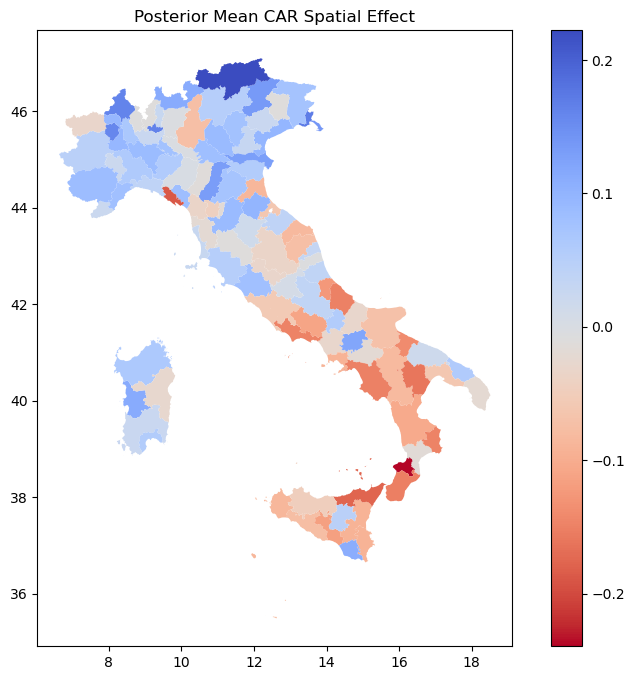

In [74]:
gdf.plot(column="spatial_effect", cmap="coolwarm_r", legend=True, figsize=(10,8))
plt.title("Posterior Mean CAR Spatial Effect")
plt.show()


### Plot regression coefficients

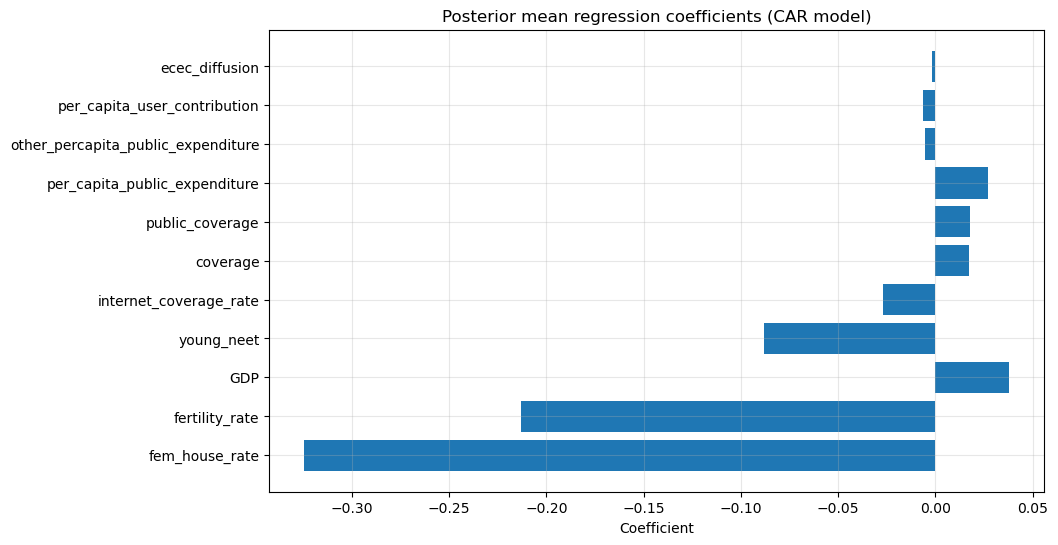

In [75]:
plt.figure(figsize=(10,6))
plt.barh(X.columns, beta_mean)
plt.title("Posterior mean regression coefficients (CAR model)")
plt.xlabel("Coefficient")
plt.grid(True, alpha=0.3)
plt.show()

### Plot sigma, tau, phi posteriors

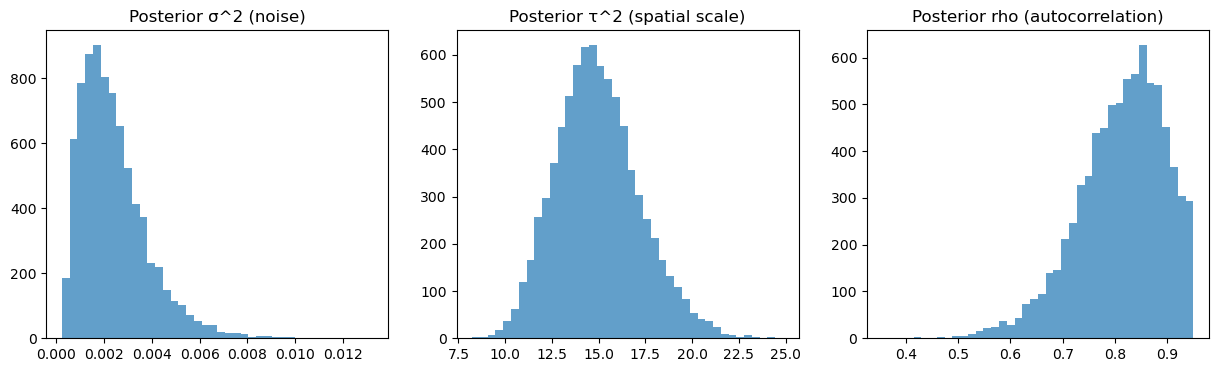

In [77]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].hist(sigma_post, bins=40, alpha=0.7)
axs[0].set_title("Posterior σ^2 (noise)")

axs[1].hist(tau_post, bins=40, alpha=0.7)
axs[1].set_title("Posterior τ^2 (spatial scale)")

axs[2].hist(rho_post, bins=40, alpha=0.7)
axs[2].set_title("Posterior rho (autocorrelation)")

plt.show()


τ 

τ controls the overall magnitude of the spatial effect:

τ big → strong spatial variation (big differences between regions)

τ small → weak spatial variation

rho

rho=how much each region is influenced by its neighbors

rho≈1 → strong spatial dependence
(classic ICAR behavior, strong clustering)

rho≈0 → almost no spatial effect
(each region behaves independently)

Interpretation:

rho close to 1 → strong spatial autocorrelation

τ large → strong spatial variation

σ small → predictors + CAR explain most of the data